<a href="https://colab.research.google.com/github/hectrony/alpha-test/blob/main/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
!pip install tensorflow

In [55]:
import numpy as np
import pandas as pd
import tensorflow as tf
import zipfile
import requests
import io
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

In [56]:
url = 'https://archive.ics.uci.edu/static/public/508/qsar+oral+toxicity.zip'

# downloading .csv file
new_file = requests.get(url)

# verifying downloading
if new_file.status_code == 200:
# opening file .zip from new_file
  with zipfile.ZipFile(io.BytesIO(new_file.content)) as file_zip:
# listing files
    print("\nFiles in .zip:", file_zip.namelist(),"\n")

# extracting file
    name_csv = file_zip.namelist()[0]  # first file
    with file_zip.open(name_csv) as file_csv:
# load .csv in pandas dataframe
      data = pd.read_csv(file_csv, sep= ';')
      print(data.head())  # first rows of dataframe

else:
  print("Download ERROR", new_file.status_code)

# convert tags 'positive' and 'negative' to 1 and  0
data.iloc[:, -1] = data.iloc[:, -1].replace({'positive': 1, 'negative': 0})


Files in .zip: ['qsar_oral_toxicity.csv'] 

   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.962  0.963  0.964  \
0  0    0    1    0    0    0    0    0    0    0  ...      0      0      0   
1  0    0    0    0    0    0    0    0    0    0  ...      0      0      1   
2  0    0    0    0    0    0    0    1    0    0  ...      0      0      0   
3  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1    0    0    0    0    0    1    0    0    0  ...      0      0      0   

   0.965  0.966  0.967  0.968  0.969  0.970  negative  
0      0      0      0      0      0      0  negative  
1      0      0      0      0      0      0  negative  
2      0      0      0      0      0      0  negative  
3      0      0      0      0      0      0  negative  
4      0      0      1      0      0      0  negative  

[5 rows x 1025 columns]


<ipython-input-56-02254030aacd>:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.iloc[:, -1] = data.iloc[:, -1].replace({'positive': 1, 'negative': 0})


In [57]:
# print(data.head())

In [58]:
# load data function
def load_data(data):
  X = data.iloc[:, :-1].values  # atriibutes
  y = data.iloc[:, -1].values   # tags
  return X, y

In [59]:
# built model function
def build_model(input_shape):
  model = Sequential()
  model.add(Input(shape=(1024,)))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))  # out layer for binary clasification
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [60]:
# viiew training  data
def graphic_training(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(loc='lower right')
  plt.show()

In [61]:
# loading data
X, y = load_data(data)

In [62]:
# spllit data -> trainning  and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# split data -> training and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# datatype convertion
X_train = X_train.astype('int32')
X_val = X_val.astype('int32')
y_train = y_train.astype('int32')
y_val = y_val.astype('int32')
X_test = X_test.astype('int32')
y_test = y_test.astype('int32')

In [63]:
# building model
model = build_model(X_train.shape[1])

# training model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9205 - loss: 0.3329 - val_accuracy: 0.9173 - val_loss: 0.2185
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9171 - loss: 0.2045 - val_accuracy: 0.9312 - val_loss: 0.1896
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9493 - loss: 0.1284 - val_accuracy: 0.9284 - val_loss: 0.1914
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9650 - loss: 0.0955 - val_accuracy: 0.9298 - val_loss: 0.2180
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9726 - loss: 0.0768 - val_accuracy: 0.9291 - val_loss: 0.2501
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9788 - loss: 0.0586 - val_accuracy: 0.9326 - val_loss: 0.2926
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9804 - loss: 0.0547 - val_accuracy: 0.9284 - val_loss: 0.3027
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9884 - loss: 0.0320 - val_accuracy: 0.

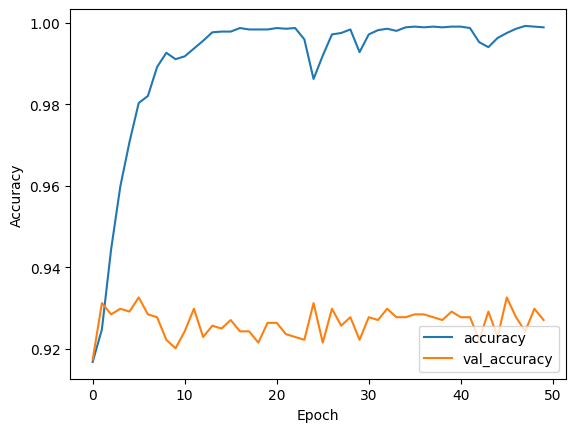

In [64]:
# view training data
graphic_training(history)

In [65]:
# review the modeel
loss, accuracy = history.model.evaluate(X_val, y_val)
print(f'Loss in the validation set:      {loss}')
print(f'Acccuracy in the validation set: {accuracy}')

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9313 - loss: 0.5750
Loss in the validation set:      0.6328511834144592
Acccuracy in the validation set: 0.9270326495170593


In [66]:
#  check the model
results = history.model.evaluate(X_test, y_test, verbose=0)

# return results in ddictionary
metrics = {
  'loss': results[0],
  'accuracy': results[1],
  }
print(metrics)

{'loss': 0.6520102620124817, 'accuracy': 0.9327403903007507}


In [67]:
def test_learning(new_data):
  predictions = history.model.predict(new_data).astype('int32')
  return predictions  # clasification: positive or negative [0] or [1]

# testing the learning model with new data
new_data = np.random.randint(low=0, high=2, size=(1, 1024))  # sample data (with 1024 columns)
results = test_learning(new_data)
print("\nGenerating new data:")
print(new_data)

if results == 0:
  results = "negative"
else:
  results = "positive"
print("\nClasification results:", results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Generating new data:
[[1 1 0 ... 0 1 1]]

Clasification results: negative
